## Check current state of tables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.colors import BoundaryNorm
from pathlib import Path
import pynwb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
import spyglass.common as sgc
import spyglass.spikesorting.v1 as sgs
from spyglass.common import Nwbfile
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition, HexMazeThetaV1, HexMazeThetaReference

# Check what is in our hex maze theta tables
print(f"\nHexMazeThetaV1 has {len(HexMazeThetaV1())} entries:")
display(HexMazeThetaV1())

print(f"\nHexMazeThetaReference has {len(HexMazeThetaReference())} entries:")
display(HexMazeThetaReference())

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-06-18 17:33:42,569][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 


HexMazeThetaV1 has 23 entries:


lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform,"theta_phase_object_id instantaneous phase [0, 2π] in radians",theta_power_object_id instantaneous power (amplitude²)
15f98b82-6683-657e-6e4c-589b020c2632,Theta 5-11 Hz,1000,Toby20250318_.nwb,07_r4_noPreTrialTimes,100,Toby20250318_A8P6GR5X10.nwb,a2cb64b9-8bd7-40af-a244-bd9c0fd15769,56ca36b6-ee74-40bb-a51a-19f9547ff903,e8181638-0b9d-41b7-bf7e-536e2521f0f3
236edb91-f3f0-34bf-eba7-363f9969a6c5,Theta 5-11 Hz,1034,IM-1594_20230725_.nwb,00_r1,1034,IM-1594_20230725_ZJNDWOFQ1H.nwb,73a5a509-c2d5-43d7-b977-37c06a7e44cf,5c73d063-6fc1-494b-b7fd-15362e5f83d0,3bf9bdf9-b8bf-47f9-a07d-7f7482289f09
24f20c68-7544-a493-612f-85c875ea3428,Theta 5-11 Hz,1034,IM-1871_20250803_.nwb,00_r1,1034,IM-1871_20250803_OVYOCWOQ5S.nwb,6c1f231a-9385-4c3f-9816-48cdfd9cb771,f9051f1c-cae8-4d50-88a5-57c27026880b,2e8b8bbc-66f6-46b4-bc1c-026e64100684
2c09f8f8-bac9-9db2-787e-10f412ee61e7,Theta 5-11 Hz,1000,IM-1871_20250731_.nwb,00_r1,1000,IM-1871_20250731_RSGW8NLGC3.nwb,3cf56f19-884c-4398-927b-c7842b3b8e5f,2969c25f-1767-4ca7-b287-b8b4eb417192,34fcda86-33b2-40bd-ad5c-c19d4603dd02
3acae88c-c8e9-a3e4-4de3-cb2e318f2ec2,Theta 5-11 Hz,1000,IM-1947_20260402_.nwb,00_r1,1000,IM-1947_20260402_SKMN3BOLM7.nwb,638bcec7-623f-4eff-ae22-17694a0bc84b,20af5e95-2583-4054-baee-12f92e988823,65d89e60-2f66-4872-a313-46dbb8afc8ff
4b852aa8-4844-5c17-261a-97bac2728ed1,Theta 5-11 Hz,1000,Toby20250327_.nwb,07_r4_noPreTrialTimes,100,Toby20250327_0PIXJMW5GA.nwb,cf9415c5-3960-458a-bae0-fb637cc87dfb,84679245-3a95-488f-a42e-2ee93c929791,c8804c78-29a8-40c1-843e-c37d3db0ce01
578f3c15-ce09-b3e8-39e8-f06120fe8570,Theta 5-11 Hz,1000,IM-1478_20220727_.nwb,00_r1,1000,IM-1478_20220727_R38TB49GRY.nwb,dc07fcfd-357e-4b9d-b32b-7fb4d0216921,de60167a-aa17-45ab-aa88-90919020bd10,5235e3c2-2090-4c24-bc53-d4f1fe12a455
595c99be-c433-697a-07a1-8727c8aacbc1,Theta 5-11 Hz,1000,IM-1478_20220720_.nwb,00_r1,1000,IM-1478_20220720_M4B8NY7XMF.nwb,a689ffcf-a0ca-4368-9ffc-df66312e71b1,80f8a467-d1c4-450e-b900-89a9c2d58103,8303f3cf-7531-4ec4-9de8-ef056035dbad
59b970f1-a77c-d2ce-c36b-35401958e0f6,Theta 5-11 Hz,1000,IM-1941_20260207_.nwb,00_r1,1000,IM-1941_20260207_L34O04SV1M.nwb,964a2e3e-2a07-4a78-a80f-482e2cadf4d5,eac1b34e-109d-4904-b3b2-4d3cf19b24d4,99d9b096-eb14-49ab-b9b3-9dfa83469f93
5b6ffc5f-eb09-ad3c-be6e-c95ae0ca462f,Theta 5-11 Hz,1034,IM-1594_20230728_.nwb,00_r1,1034,IM-1594_20230728_O4U0BP658F.nwb,372e5bc8-8af8-41aa-bf09-14cf1e9a0751,88312fbd-6707-4298-99f2-01354fd57b3a,6b1c92f6-3f32-4f84-b3a1-2095a4910184



HexMazeThetaReference has 1 entries:


lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,"reference_name label for this electrode set, e.g. ""radiatum""",electrode_ids list of electrode ids to average over,description optional note about how the set was chosen
578f3c15-ce09-b3e8-39e8-f06120fe8570,Theta 5-11 Hz,1000,IM-1478_20220727_.nwb,00_r1,1000,theta_reference_1,=BLOB=,striatum radiatum (k=6 cluster 0)


In [5]:
nwb_file_name = "IM-1478_20220719_.nwb"
session_id = nwb_file_name.replace("_.nwb", "")
key = {"nwb_file_name": nwb_file_name}
CURATION_ID = 1   # 0=initial, 1=not-whitened, 3=whitened
PREPROC_PARAM_NAME = "franklab_tetrode_hippocampus" # should be "default", sometimes is "franklab_tetrode_hippocampus"

# Save figures as PDFs, one folder per session
FIG_DIR = Path("figures") / session_id
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Save a figure as a PDF into FIG_DIR."""
    path = FIG_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight")
    print(f"saved {path}")

display(HexMazeThetaV1() & key)
display(HexMazeThetaReference() & key)

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform,"theta_phase_object_id instantaneous phase [0, 2π] in radians",theta_power_object_id instantaneous power (amplitude²)
9bd18c6f-4cf3-ac6b-2550-85fd5feadb05,Theta 5-11 Hz,1000,IM-1478_20220719_.nwb,00_r1,1000,IM-1478_20220719_P0VHPC4NKY.nwb,048d60d1-145b-47f5-9c20-d9d5fbfbf4b1,b5dfa8bd-df84-4fd0-8282-181074e34a8c,c5795c90-9431-49e4-b4a9-f555da36bac0


lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,"reference_name label for this electrode set, e.g. ""radiatum""",electrode_ids list of electrode ids to average over,description optional note about how the set was chosen


## Get electrodes with good units

In [6]:
# default-preprocessed sortings for this session. proj() keeps only the primary
# key (drops nwb_file_name, the dependent attr the v1 tables can't join on).
recordings = (sgs.SpikeSortingRecordingSelection & key & {"preproc_param_name": PREPROC_PARAM_NAME}).proj()
curated = (sgs.CurationV1 * sgs.SpikeSortingSelection * recordings) & {"curation_id": CURATION_ID}

# Get units from every curation (use as_dataframe to skip the slow recording rebuild)
units = pd.concat(
    sgs.CurationV1.get_sorting(k, as_dataframe=True)
    for k in curated.fetch("sorting_id", "curation_id", as_dict=True)
)

# Keep only well-isolated single units (drop anything tagged noise / reject / mua)
good = units[~units["curation_label"].astype(str).str.contains("noise|reject|mua", case=False)]

# Get peak_channel for each good unit
electrodes_with_units = sorted({int(c) for c in good["peak_channel"].dropna()})

print(f"{len(good)} accepted units on {len(electrodes_with_units)} electrodes")
print(electrodes_with_units)

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

62 accepted units on 29 electrodes
[61, 132, 142, 147, 150, 151, 157, 158, 159, 160, 165, 166, 167, 172, 173, 174, 182, 183, 190, 197, 198, 199, 217, 220, 221, 222, 232, 243, 249]


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:590: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "MFC_200/250-0.66_40mm_MF2.5_FLT" to a new DeviceModel.
  return func(self, *remaining_args)
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:590: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "iFMC7-G2" to a new DeviceModel.
  return func(self, *remaining_args)
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:590: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "M470F3" to a new DeviceModel.
  return func(self, *remaining_args)
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py

## Plot raw traces so we can see what channels have spikes. Star the electrodes with good units

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

saved figures/IM-1478_20220719/IM-1478_20220719_raw_traces.pdf


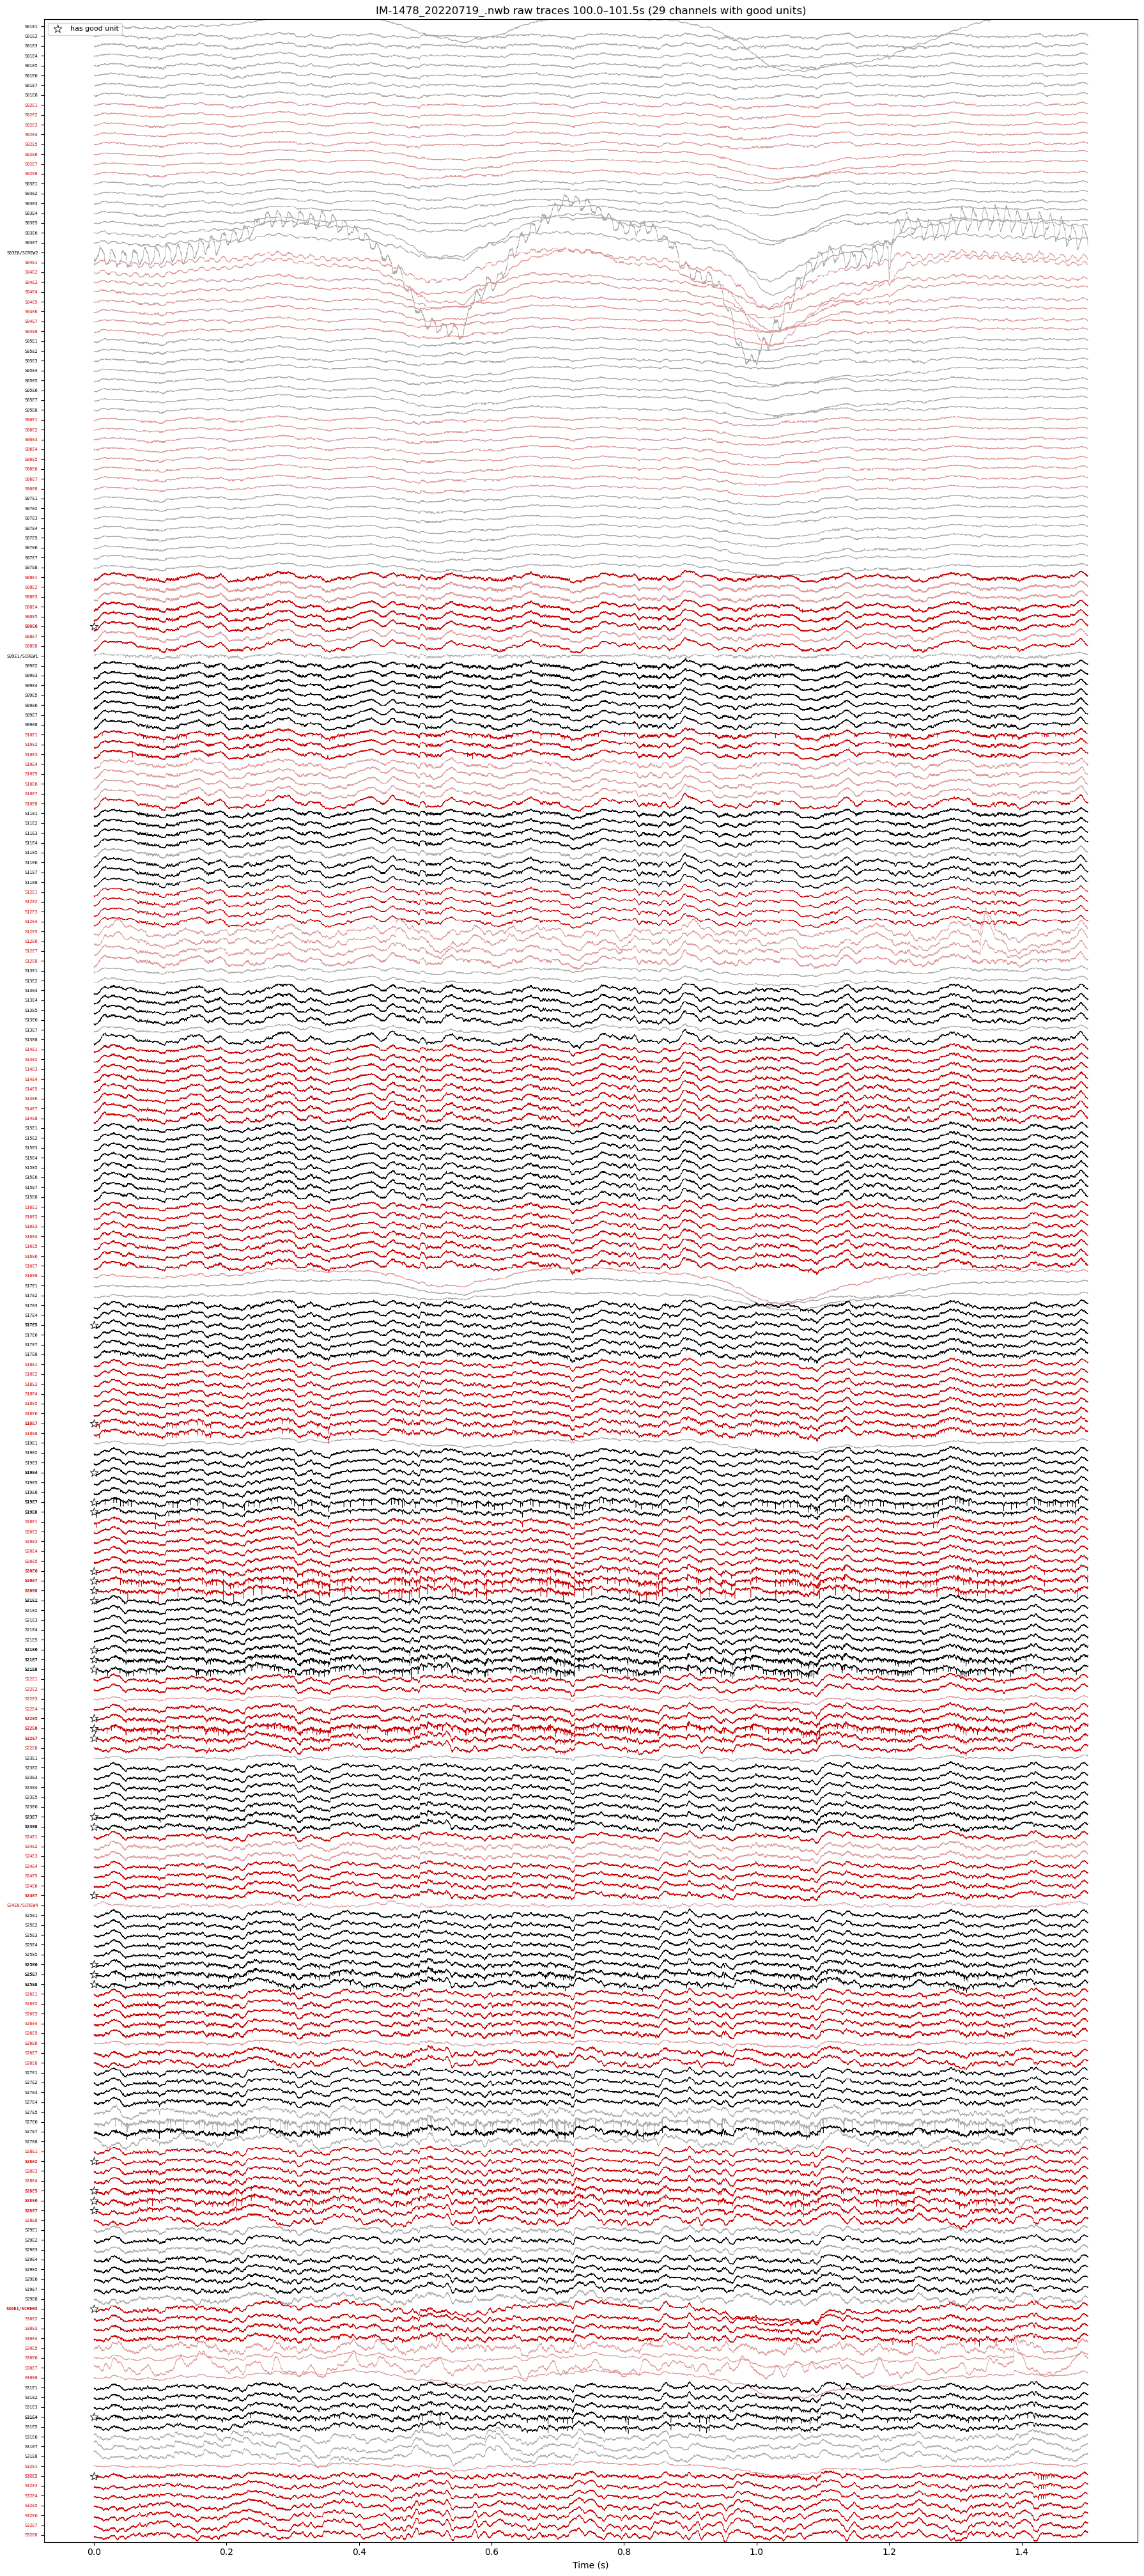

In [7]:
# Time window to plot (seconds from the start of the recording)
start_time, duration = 100.0, 1.5

# Electrodes that carry a good unit (from the units cell above)
unit_elecs = set(electrodes_with_units)

# Open the raw NWB that spyglass tracks and pull a short window of all channels
with pynwb.NWBHDF5IO(Nwbfile().get_abs_path(nwb_file_name), "r", load_namespaces=True) as io:
    nwbf = io.read()
    eseries = nwbf.acquisition["ElectricalSeries"]
    ts = np.asarray(eseries.timestamps)

    # Convert the time window to sample indices
    i0, i1 = int(np.searchsorted(ts, start_time)), int(np.searchsorted(ts, start_time + duration))
    t = ts[i0:i1] - ts[i0]                                  # time within the window (s)
    data = np.asarray(eseries.data[i0:i1, :], dtype=float)  # raw traces (n_time, n_chan) in µV

    # Electrode-table row for each data column (gives geometry + bad-channel tags)
    elec = nwbf.electrodes.to_dataframe().iloc[list(eseries.electrodes.data)]

# Remember each electrode's data column, and keep its electrode_id (== peak_channel id)
elec["data_col"] = range(len(elec))
elec["electrode_id"] = elec.index

# Order channels left-to-right by shank, then top-to-bottom within shank (rel_y descending)
elec = elec.sort_values(["probe_shank", "rel_y"], ascending=[True, False]).reset_index(drop=True)

# Set the trace scale from good channels only
scale = 4 * np.nanstd(data[:, elec.loc[elec["bad_channel"] == 0, "data_col"].astype(int)])

# Plot each channel as a stacked trace, colored by shank (bad channels faded)
n = len(elec)
fig, ax = plt.subplots(figsize=(18, 0.15 * n + 2))
rows = []        # (y position, electrode name, shank color, has-unit) per channel
unit_ys = []     # y positions of channels with a good unit, for the stars
for k, row in elec.iterrows():
    y = n - 1 - k # stack top-to-bottom (first row on top)

    # Alternate trace color by shank; fade bad channels to gray
    base = "black" if row["probe_shank"] % 2 == 0 else "#cc0000"
    color = base if row["bad_channel"] == 0 else ("#aaaaaa" if base == "black" else "#dd9999")
    ax.plot(t, data[:, int(row["data_col"])] / scale + y, color=color, lw=0.4, rasterized=True)

    # Note channels that carry a good unit so we can mark them after the loop
    has_unit = row["electrode_id"] in unit_elecs
    if has_unit:
        unit_ys.append(y)
    rows.append((y, row["electrode_name"], base, has_unit))

# Star the channels that carry a good unit (white fill + black edge to match the theta phase plot)
ax.scatter([t[0]] * len(unit_ys), unit_ys, marker="*", s=90, c="white",
           edgecolors="black", linewidths=0.6, zorder=5, clip_on=False, label="has good unit")

# Label each trace with its electrode name, colored by shank; bold if it has a unit
ax.set_yticks([r[0] for r in rows])
ax.set_yticklabels([r[1] for r in rows], fontsize=5, fontfamily="monospace")
for lab, (_, _, base, has_unit) in zip(ax.get_yticklabels(), rows):
    lab.set_color(base)
    lab.set_fontweight("bold" if has_unit else "normal")

ax.set_ylim(-0.7, n - 0.3)
ax.set_xlabel("Time (s)")
ax.legend(loc="upper left", fontsize=8)
ax.set_title(f"{nwb_file_name} raw traces {start_time}–{start_time + duration}s "
             f"({len(unit_elecs)} channels with good units)")
plt.tight_layout()
save_fig(fig, f"{session_id}_raw_traces")
plt.show()


## Pick a set of reference electrodes for theta power and phase

Compute theta power/phase metrics and plot on probe geometry

[2026-06-18 17:37:07,766][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-06-18 17:37:07,778][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

Reference electrode: 254   (n = 34148 samples)
Preferred theta phase at reference electrode: -121 deg
saved figures/IM-1478_20220719/IM-1478_20220719_theta_metrics_probe_geometry.pdf


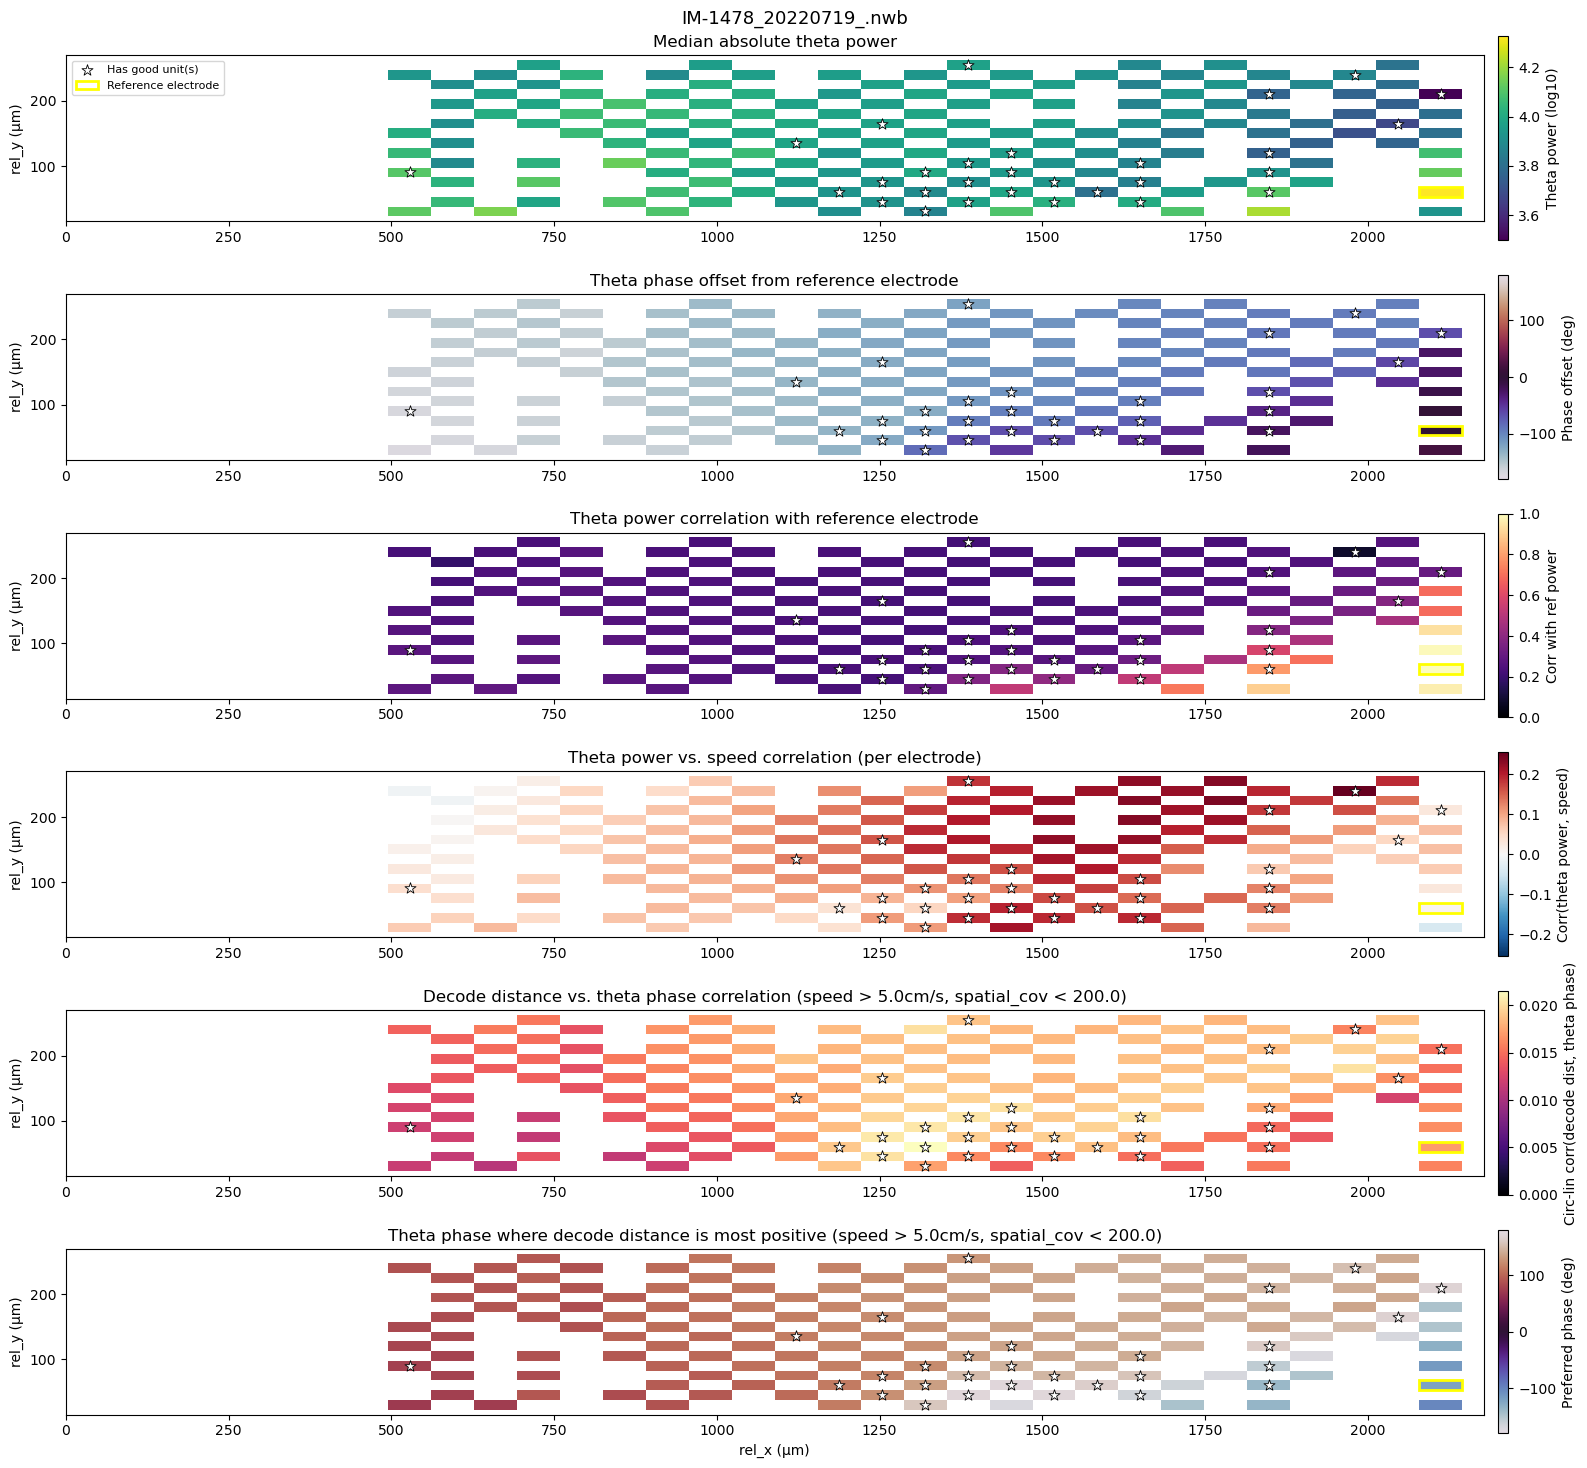

In [8]:
SPEED_THRESH = 5.0       # cm/s: only keep running times (for decode-distance measures only)
SPATIAL_COV_MAX = 200.0  # only keep confident deocdes (for decode-distance measures only)
#HIGH_THETA_PCT = 50.0    # optionally keep only high theta-power times (based on the reference electrode)
SUBSAMPLE = 50

# Get theta phase and theta power for each electrode (df columns "electrode N", indexed by time)
phase_df = (HexMazeThetaV1() & {"nwb_file_name": nwb_file_name}).fetch1_theta_phase()
power_df = (HexMazeThetaV1() & {"nwb_file_name": nwb_file_name}).fetch1_theta_power()
# Subsample theta power and phase so they aren't huge
theta_phase_sub, theta_power_sub = phase_df.iloc[::SUBSAMPLE], power_df.iloc[::SUBSAMPLE]

# Get probe geometry (rel_x, rel_y) and bad_channel tag for each electrode
elec_table = pd.DataFrame(
    (sgc.Electrode * sgc.Probe.Electrode & {"nwb_file_name": nwb_file_name})
    .fetch("name", "rel_x", "rel_y", "bad_channel", as_dict=True)
).set_index("name")
elec_table = elec_table.loc[sorted(elec_table.index, key=int)]
is_bad = elec_table["bad_channel"].astype(str).str.lower().isin(["true", "1"])

# Find the good channel with the highest median theta power so we can use that as our reference electrode
median_theta_power = power_df.median()
median_theta_power.index = median_theta_power.index.str.split().str[-1] # Convert index from "electrode N" to "N"
good_power = median_theta_power[[n for n in median_theta_power.index if not is_bad.get(n, True)]]
ref_name = good_power.idxmax()
ref_col = f"electrode {ref_name}"

# Fetch and align speed, decode distance, and spatial cov to subsampled theta timestamps
decode_df = (HexMazeDecodedPosition & {"nwb_file_name": nwb_file_name}).fetch1_dataframe()
speed = decode_df["speed"].reindex(theta_phase_sub.index, method="nearest")
decode_dist = decode_df["decode_distance"].reindex(theta_phase_sub.index, method="nearest")
spatial_coverage = decode_df["spatial_cov"].reindex(theta_phase_sub.index, method="nearest")

# 1: Get theta phase lag of each electrode relative to the reference electrode
reference_theta_phase = theta_phase_sub[ref_col].values
theta_phase_offsets = {name: np.degrees(np.angle(np.mean(np.exp(
              1j * (theta_phase_sub[f"electrode {name}"].values - reference_theta_phase)))))
           for name in elec_table.index[~is_bad.values]}

# 2: Get correlation between each electrode's theta power envelope and the reference electrode's
theta_power_corr = theta_power_sub.corrwith(theta_power_sub[ref_col])
theta_power_corr.index = theta_power_corr.index.str.split().str[-1]

# 3: Get pearson correlation of theta power with speed for all electrodes
power_speed_corr = theta_power_sub.corrwith(speed)
power_speed_corr.index = power_speed_corr.index.str.split().str[-1] # Convert index from "electrode N" to "N"

# Filter by speed and spatial_cov for decode distance based measures
# (Uncomment the theta_power_thresh lines below to also filter for high theta times)
# theta_power_thresh = np.nanpercentile(theta_power_sub[ref_col], HIGH_THETA_PCT)
times_to_keep = (
    (speed.values >= SPEED_THRESH)
    # & (theta_power_sub[ref_col].values >= theta_power_thresh)
    & (spatial_coverage.values < SPATIAL_COV_MAX)
    & decode_dist.notna().values
)

kept_phase = theta_phase_sub.values[times_to_keep]      # (n_samples, n_electrodes) theta phase in radians
kept_decode_dist = decode_dist.values[times_to_keep]    # (n_samples,) signed decode distance from rat
cos_phase, sin_phase = np.cos(kept_phase), np.sin(kept_phase)

# Vectorized pearson corr of `vector` against each column of `matrix` (one value per electrode)
def columnwise_pearson(matrix, vector):
    matrix_centered = matrix - matrix.mean(0)
    vector_centered = vector - vector.mean()
    return (matrix_centered * vector_centered[:, None]).sum(0) / np.sqrt(
        (matrix_centered ** 2).sum(0) * (vector_centered ** 2).sum())

corr_dist_cos = columnwise_pearson(cos_phase, kept_decode_dist)   # corr(decode distance, cos phase) per electrode
corr_dist_sin = columnwise_pearson(sin_phase, kept_decode_dist)   # corr(decode distance, sin phase) per electrode
# corr(cos, sin) per electrode
cos_centered, sin_centered = cos_phase - cos_phase.mean(0), sin_phase - sin_phase.mean(0)
corr_cos_sin = (cos_centered * sin_centered).sum(0) / np.sqrt((cos_centered ** 2).sum(0) * (sin_centered ** 2).sum(0))

# 4: Get correlation of decode distance with theta phase for each electrode 
# Theta phase is circular so use Mardia's circular-linear correlation (which handles this by combining 
# decode distance's correlation with cos(phase) and with sin(phase) into one number in [0, 1])
# (0 = no relationship to phase, 1 = phase fully predicts decode distance)
# Says how strong the theta phase / decode distance relationship is, but not where peak is (see 5 for that)
circ_lin_corr = np.sqrt(
    (corr_dist_cos ** 2 + corr_dist_sin ** 2 - 2 * corr_dist_cos * corr_dist_sin * corr_cos_sin)
    / (1 - corr_cos_sin ** 2))
dist_phase_corr = pd.Series(circ_lin_corr, index=[c.split()[-1] for c in theta_phase_sub.columns])

# 5: Get theta phase at which decode distance is most positive (decoded position furthest ahead of the rat)
# First-harmonic fit decode_distance ~ a*cos(phase) + b*sin(phase) peaks at phase = atan2(b, a); 
# the correlation slopes corr_dist_cos, corr_dist_sin give the same peak angle
pref_phase_deg = np.degrees(np.arctan2(corr_dist_sin, corr_dist_cos))   # [-180, 180]
dist_pref_phase = pd.Series(pref_phase_deg, index=[c.split()[-1] for c in theta_phase_sub.columns])

print(f"Reference electrode: {ref_name}   (n = {times_to_keep.sum()} samples)")
print(f"Preferred theta phase at reference electrode: {dist_pref_phase[ref_name]:.0f} deg")

# Add every metric to the electrode geometry table for plotting (NaN out bad channels)
electrode_geometry = elec_table.copy()
electrode_geometry["phase_offset_deg"] = pd.Series(theta_phase_offsets)
electrode_geometry["theta_power"] = median_theta_power
electrode_geometry["power_corr"] = theta_power_corr
electrode_geometry["power_speed_corr"] = power_speed_corr
electrode_geometry["dist_phase_corr"] = dist_phase_corr
electrode_geometry["dist_pref_phase_deg"] = dist_pref_phase
metric_cols = ["phase_offset_deg", "theta_power", "power_corr",
               "power_speed_corr", "dist_phase_corr", "dist_pref_phase_deg"]
electrode_geometry.loc[is_bad, metric_cols] = np.nan
has_unit = electrode_geometry.index.astype(int).isin(set(electrodes_with_units))

# Get box size to plot based on the min spacing between electrodes rel_x and rel_y
def min_spacing(v):
    d = np.diff(np.unique(v)); d = d[d > 0]
    return d.min() if len(d) else 1.0
box_width, box_height = min_spacing(electrode_geometry["rel_x"].values), min_spacing(electrode_geometry["rel_y"].values)

# Draw probe geometry with boxes for each electrode colored by 'values'
# Add stars to the electrodes with good units and outline the reference electrode in yellow
def geometry_boxes(ax, values, cmap_name, label, clim=None, n_categories=None, highlight=None):
    # Discrete colormap when coloring by category (e.g. layer labels), else continuous
    if n_categories is not None:
        cmap = plt.colormaps[cmap_name].resampled(n_categories).copy()
        norm = BoundaryNorm(np.arange(-0.5, n_categories + 0.5), n_categories)
    else:
        cmap, norm = plt.colormaps[cmap_name].copy(), None
    cmap.set_bad("white")
    boxes = [Rectangle((x - box_width/2, y - box_height/2), box_width, box_height) 
             for x, y in zip(electrode_geometry["rel_x"], electrode_geometry["rel_y"])]
    patch_collection = PatchCollection(boxes, cmap=cmap, norm=norm)
    patch_collection.set_array(np.ma.masked_invalid(values))
    if clim and n_categories is None: patch_collection.set_clim(*clim)
    ax.add_collection(patch_collection)
    # Mark electrodes that have good units with a star
    ax.scatter(electrode_geometry.loc[has_unit, "rel_x"], electrode_geometry.loc[has_unit, "rel_y"], marker="*", s=70,
               c="white", edgecolors="black", linewidths=0.6, zorder=5, label="Has good unit(s)")
    # Highlight reference electrode in yellow
    ax.add_patch(Rectangle((electrode_geometry.loc[ref_name, "rel_x"] - box_width/2, 
                            electrode_geometry.loc[ref_name, "rel_y"] - box_height/2),
                 box_width, box_height, fill=False, edgecolor="yellow", linewidth=2, label="Reference electrode"))
    # Outline a custom set of electrodes (e.g. the chosen reference set) in red
    if highlight is not None:
        for i, e in enumerate(highlight):
            ax.add_patch(Rectangle((electrode_geometry.loc[e, "rel_x"] - box_width/2,
                                    electrode_geometry.loc[e, "rel_y"] - box_height/2),
                         box_width, box_height, fill=False, edgecolor="red", linewidth=2,
                         zorder=6, label="Selected reference" if i == 0 else None))
    ax.set_xlim(electrode_geometry["rel_x"].min() - box_width, electrode_geometry["rel_x"].max() + box_width)
    ax.set_ylim(electrode_geometry["rel_y"].min() - box_height, electrode_geometry["rel_y"].max() + box_height)
    # Shape the axes box based on min/max x/y coords (otherwise the colorbar is huge and weird)
    xspan = (electrode_geometry["rel_x"].max() + box_width) - (electrode_geometry["rel_x"].min() - box_width)
    yspan = (electrode_geometry["rel_y"].max() + box_height) - (electrode_geometry["rel_y"].min() - box_height)
    ax.set_box_aspect(yspan / xspan)
    ax.set_ylabel("rel_y (µm)")
    plt.colorbar(patch_collection, ax=ax, label=label, fraction=0.02, pad=0.01,
                 ticks=range(n_categories) if n_categories is not None else None)

# Get colormap limits
speed_corr_limit = np.nanmax(np.abs(electrode_geometry["power_speed_corr"].values)) # symmetric scale around 0
circ_lin_corr_limit = np.nanmax(electrode_geometry["dist_phase_corr"].values)

# Big plot with all per-electrode measures. Pass highlight=[electrode names] to outline a
# chosen set (e.g. the reference electrodes) on every panel.
def plot_geometry_panels(highlight=None, save_name=None):
    fig, axes = plt.subplots(6, 1, figsize=(16, 15))
    geometry_boxes(axes[0], np.log10(electrode_geometry["theta_power"].values), "viridis",
                   "Theta power (log10)", highlight=highlight)
    geometry_boxes(axes[1], electrode_geometry["phase_offset_deg"].values, "twilight",
                   "Phase offset (deg)", clim=(-180, 180), highlight=highlight)
    geometry_boxes(axes[2], electrode_geometry["power_corr"].values, "magma",
                   "Corr with ref power", clim=(0, 1), highlight=highlight)
    geometry_boxes(axes[3], electrode_geometry["power_speed_corr"].values, "RdBu_r",
                   "Corr(theta power, speed)", clim=(-speed_corr_limit, speed_corr_limit), highlight=highlight)
    geometry_boxes(axes[4], electrode_geometry["dist_phase_corr"].values, "magma",
                   "Circ-lin corr(decode dist, theta phase)", clim=(0, circ_lin_corr_limit), highlight=highlight)
    geometry_boxes(axes[5], electrode_geometry["dist_pref_phase_deg"].values, "twilight",
                   "Preferred phase (deg)", clim=(-180, 180), highlight=highlight)
    axes[0].set_title("Median absolute theta power")
    axes[1].set_title("Theta phase offset from reference electrode")
    axes[2].set_title("Theta power correlation with reference electrode")
    axes[3].set_title("Theta power vs. speed correlation (per electrode)")
    axes[4].set_title(f"Decode distance vs. theta phase correlation (speed > {SPEED_THRESH}cm/s, spatial_cov < {SPATIAL_COV_MAX})")
    axes[5].set_title(f"Theta phase where decode distance is most positive (speed > {SPEED_THRESH}cm/s, spatial_cov < {SPATIAL_COV_MAX})")
    axes[0].legend(loc="upper left", fontsize=8)
    axes[5].set_xlabel("rel_x (µm)")
    fig.suptitle(nwb_file_name, fontsize=13)
    plt.tight_layout()
    if save_name:
        save_fig(fig, save_name)
    plt.show()


plot_geometry_panels(save_name=f"{session_id}_theta_metrics_probe_geometry")

Ccomparison between number of layers (higher silhouette / lower Davies-Bouldin = better separated):
(Note we don't expect these to be super informative because we have a smooth gradient vs real clusters)


,mean_silhouette,davies_bouldin
k,,
3,0.532,0.688
4,0.493,0.647
5,0.500,0.713
6,0.433,0.723



Split into 3 layers (overall silhouette = 0.532):


,n,phase_mean_deg,phase_R,phase_std_deg,log_power_mean,log_power_std,mean_silhouette
layer,,,,,,,
0,78,-102.5,0.948,18.7,3.90,0.09,0.528
1,17,-28.6,0.940,20.2,4.00,0.15,0.332
2,65,-151.2,0.984,10.3,4.01,0.06,0.589


saved figures/IM-1478_20220719/IM-1478_20220719_layers_k3.pdf


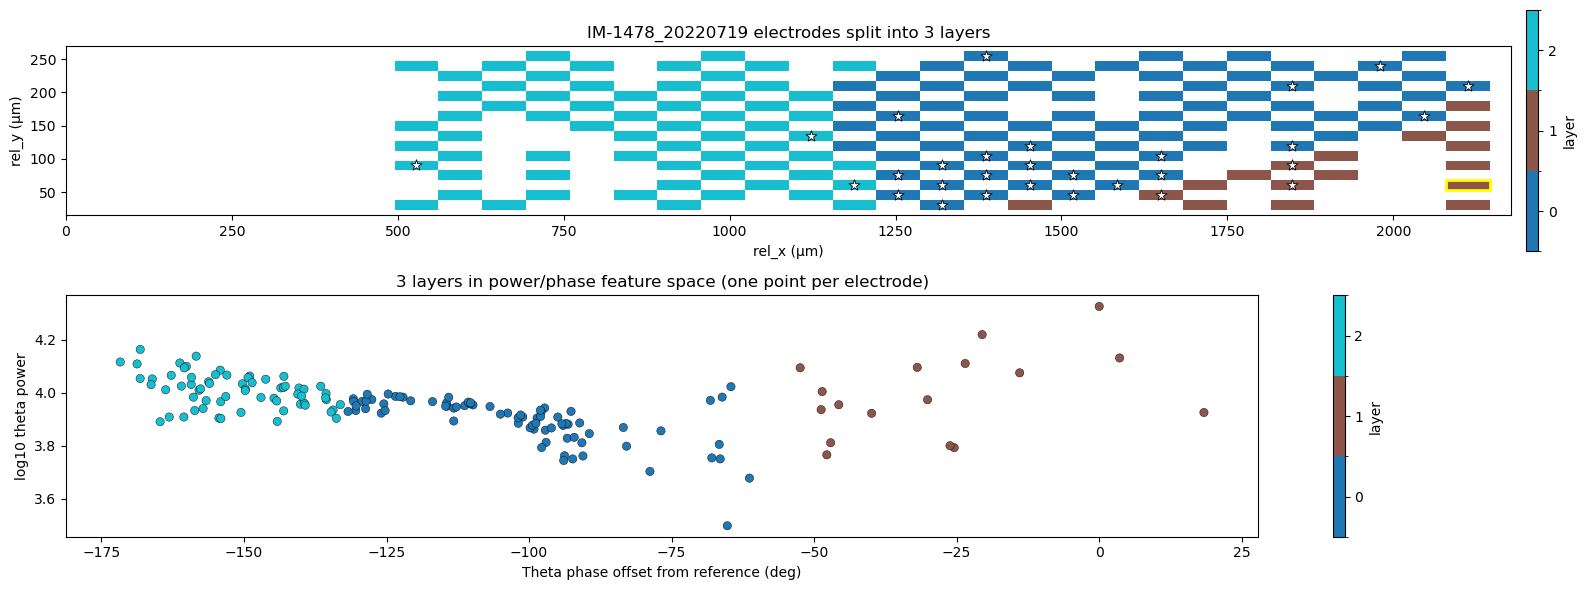


Split into 4 layers (overall silhouette = 0.493):


,n,phase_mean_deg,phase_R,phase_std_deg,log_power_mean,log_power_std,mean_silhouette
layer,,,,,,,
0,42,-133.6,0.992,7.5,3.97,0.03,0.551
1,59,-94.8,0.969,14.3,3.87,0.09,0.501
2,42,-157.6,0.994,6.3,4.02,0.07,0.505
3,17,-28.6,0.940,20.2,4.00,0.15,0.297


saved figures/IM-1478_20220719/IM-1478_20220719_layers_k4.pdf


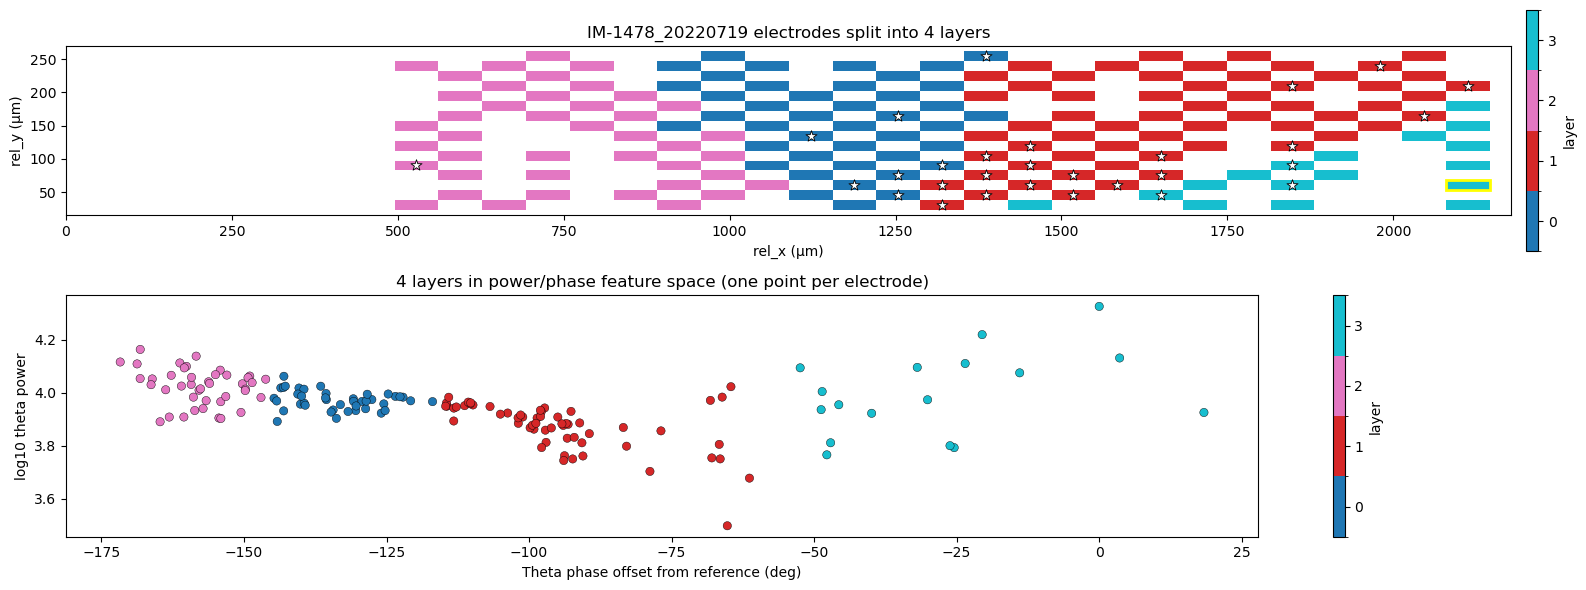


Split into 5 layers (overall silhouette = 0.500):


,n,phase_mean_deg,phase_R,phase_std_deg,log_power_mean,log_power_std,mean_silhouette
layer,,,,,,,
0,52,-99.5,0.986,9.5,3.89,0.07,0.590
1,40,-158.2,0.995,6.0,4.02,0.07,0.515
2,19,-51.1,0.968,14.6,3.87,0.15,0.193
3,6,-6.1,0.967,14.8,4.13,0.12,0.451
4,43,-134.6,0.992,7.4,3.97,0.04,0.518


saved figures/IM-1478_20220719/IM-1478_20220719_layers_k5.pdf


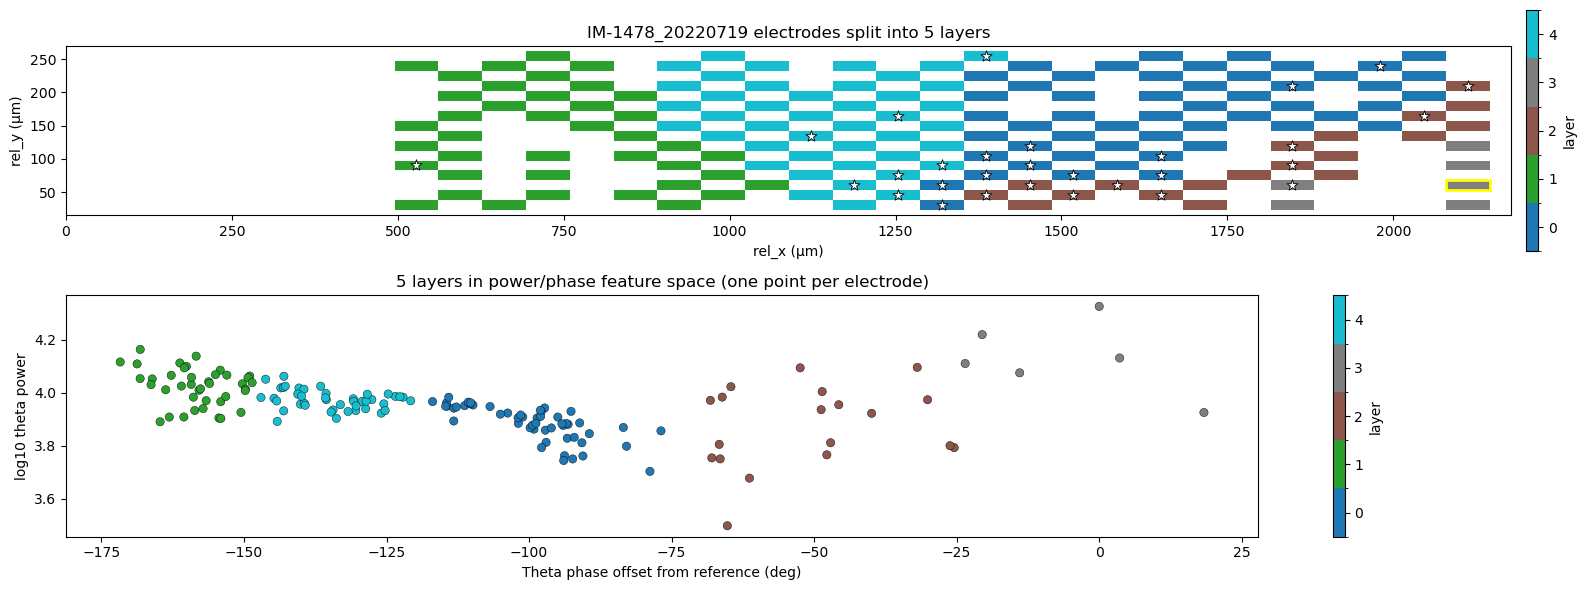


Split into 6 layers (overall silhouette = 0.433):


,n,phase_mean_deg,phase_R,phase_std_deg,log_power_mean,log_power_std,mean_silhouette
layer,,,,,,,
0,32,-120.6,0.991,7.9,3.96,0.02,0.483
1,33,-160.0,0.996,4.9,4.02,0.07,0.444
2,12,-39.0,0.984,10.3,3.94,0.12,0.402
3,46,-89.9,0.977,12.4,3.85,0.09,0.414
4,32,-142.1,0.996,5.4,3.99,0.05,0.425
5,5,-2.5,0.972,13.7,4.14,0.14,0.334


saved figures/IM-1478_20220719/IM-1478_20220719_layers_k6.pdf


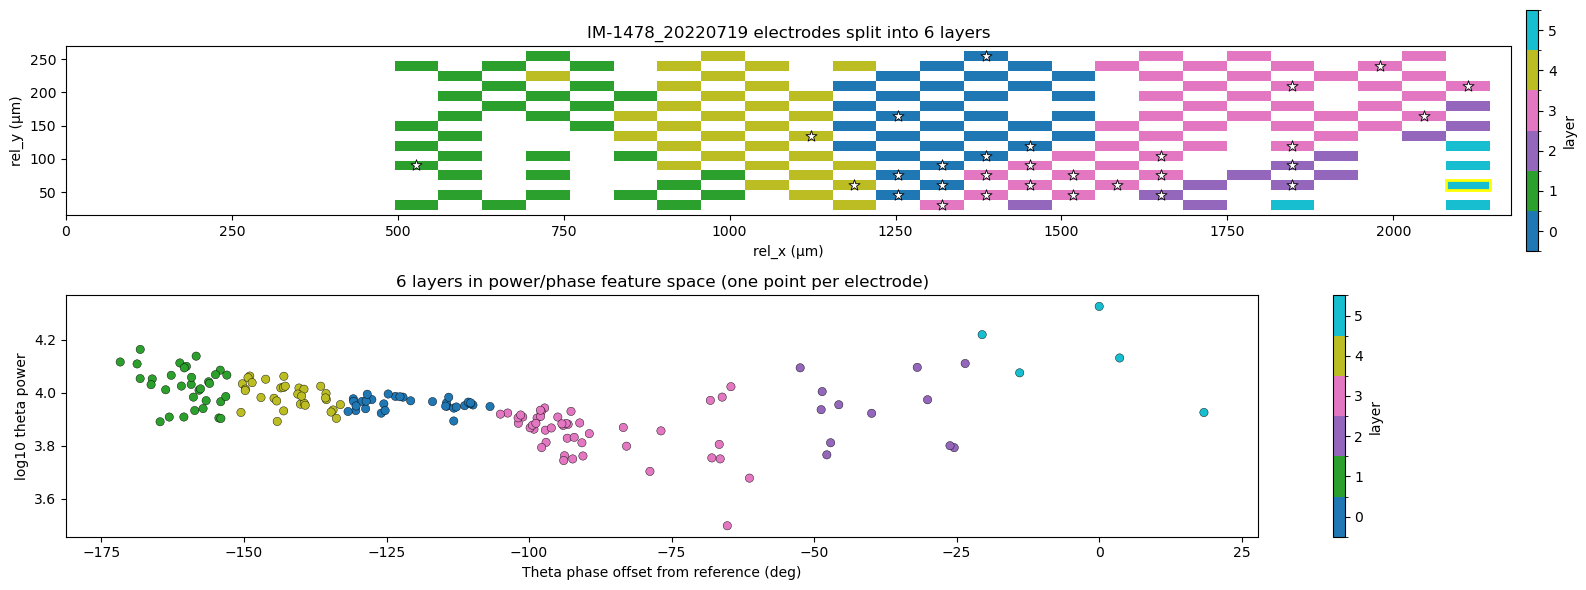

In [9]:
# Group electrodes into layers based on theta metrics:
# Electrodes in the same layer should have consistent theta phase (offset from the reference) and theta power
# Reuses electrode_geometry / is_bad / has_unit / geometry_boxes from the cell above.
LAYER_COUNTS = [3, 4, 5, 6]   # candidate numbers of layers: compared and plotted for each
W_PHASE = 2.0              # weight of theta phase relative to theta power
W_POWER = 1.0              # weight of theta power

# Good channels with the measures we cluster on
good_mask = ~is_bad & electrode_geometry[["phase_offset_deg", "theta_power"]].notna().all(axis=1)
good_electrodes = electrode_geometry.loc[good_mask]
phase_rad = np.radians(good_electrodes["phase_offset_deg"].values)
log_power = np.log10(good_electrodes["theta_power"].values) # power spans orders of magnitude

# Build the feature matrix. Circular theta phase becomes [cos, sin] so the 360 deg wrap is
# handled. Standardize so phase and power are comparable, then up-weight phase.
features = StandardScaler().fit_transform(
    np.column_stack([np.cos(phase_rad), np.sin(phase_rad), log_power])
) * np.array([W_PHASE, W_PHASE, W_POWER])

# Compare numbers of layers on the metrics that actually discriminate (phase_R saturates
# near 1 at any k because theta phase is a smooth depth gradient, so it can't pick k).
# Higher silhouette = better separated; lower Davies-Bouldin = better separated.
scan_rows = []
for k in LAYER_COUNTS:
    trial = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(features)
    scan_rows.append({
        "k": k,
        "mean_silhouette": round(silhouette_score(features, trial), 3),
        "davies_bouldin": round(davies_bouldin_score(features, trial), 3),
    })
print("Ccomparison between number of layers (higher silhouette / lower Davies-Bouldin = better separated):")
print("(Note we don't expect these to be super informative because we have a smooth gradient vs real clusters)")
display(pd.DataFrame(scan_rows).set_index("k"))


def circular_stats(angles_rad):
    """Mean angle (deg) and concentration R of a set of angles.
    R is the mean resultant length: 1 = all identical, 0 = uniformly spread."""
    resultant = np.mean(np.exp(1j * angles_rad))
    R = np.abs(resultant)
    circular_std_deg = np.degrees(np.sqrt(-2 * np.log(R))) if R > 0 else np.inf
    return np.degrees(np.angle(resultant)), R, circular_std_deg


def layers_for_k(n_layers):
    """Cluster electrodes into n_layers. Label numbers are arbitrary (KMeans order)."""
    return KMeans(n_clusters=n_layers, n_init=10, random_state=0).fit_predict(features)


# Show the grouping for each requested number of layers
for n_layers in LAYER_COUNTS:
    layer = layers_for_k(n_layers)
    sample_silhouette = silhouette_samples(features, layer)  # per-electrode separation score
    print(f"\nSplit into {n_layers} layers (overall silhouette = {silhouette_score(features, layer):.3f}):")

    # Per-layer consistency: tight phase (high R / low std) and small power spread = consistent
    rows = []
    for lyr in range(n_layers):
        in_layer = layer == lyr
        phase_mean, phase_R, phase_std = circular_stats(phase_rad[in_layer])
        rows.append({
            "layer": lyr,
            "n": int(in_layer.sum()),
            "phase_mean_deg": round(phase_mean, 1),
            "phase_R": round(phase_R, 3),              # 1 = identical phase, 0 = spread out
            "phase_std_deg": round(phase_std, 1),      # circular spread of phase within the layer
            "log_power_mean": round(log_power[in_layer].mean(), 2),
            "log_power_std": round(log_power[in_layer].std(), 2),
            "mean_silhouette": round(sample_silhouette[in_layer].mean(), 3),
        })
    display(pd.DataFrame(rows).set_index("layer"))

    # Full-length label array for the geometry plot (NaN for bad / excluded channels)
    layer_full = pd.Series(np.nan, index=electrode_geometry.index)
    layer_full.loc[good_electrodes.index] = layer

    # Geometry map + feature-space scatter for this grouping
    fig, axes = plt.subplots(2, 1, figsize=(16, 6))
    geometry_boxes(axes[0], layer_full.values, "tab10", "layer", n_categories=n_layers)
    axes[0].set_title(f"{session_id} electrodes split into {n_layers} layers")
    axes[0].set_xlabel("rel_x (µm)")

    discrete_cmap = plt.colormaps["tab10"].resampled(n_layers)
    layer_norm = BoundaryNorm(np.arange(-0.5, n_layers + 0.5), n_layers)
    scatter = axes[1].scatter(good_electrodes["phase_offset_deg"], log_power, c=layer,
                              cmap=discrete_cmap, norm=layer_norm,
                              edgecolors="k", linewidths=0.3)
    axes[1].set_xlabel("Theta phase offset from reference (deg)")
    axes[1].set_ylabel("log10 theta power")
    axes[1].set_title(f"{n_layers} layers in power/phase feature space (one point per electrode)")
    plt.colorbar(scatter, ax=axes[1], label="layer", ticks=range(n_layers))
    plt.tight_layout()
    save_fig(fig, f"{session_id}_layers_k{n_layers}")
    plt.show()

## Manual step! 
### Based on the above plots, pick the layer we want to use for our reference electrodes

5 clusters; using layer 2 as the reference (19 electrodes): 
['167', '174', '175', '183', '190', '199', '206', '207', '214', '220', '221', '228', '229', '230', '243', '244', '249', '250', '251']
saved figures/IM-1478_20220719/IM-1478_20220719_theta_reference_probe_geometry.pdf


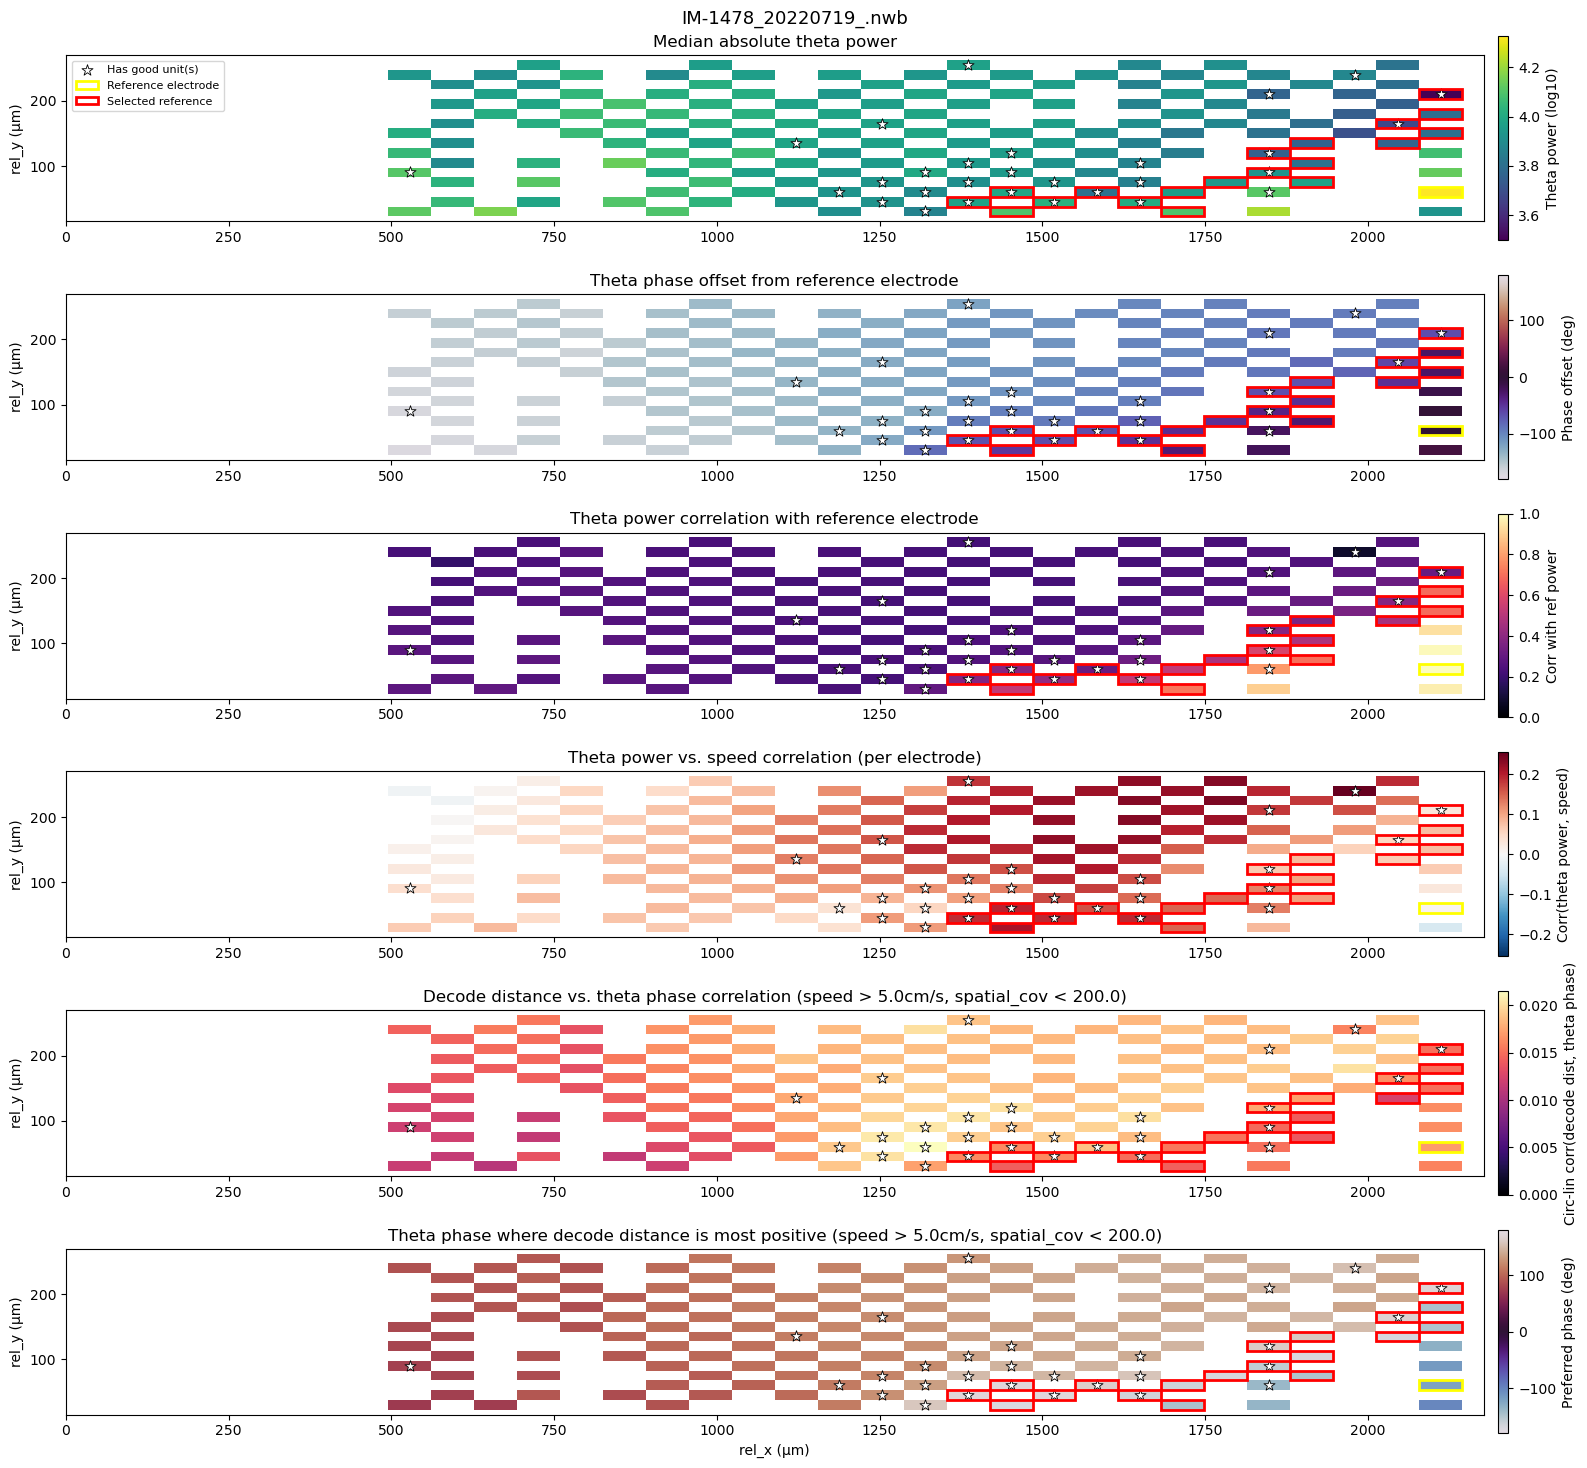

In [10]:
# Pick the number of clusters/layers (k) and which cluster to use as the theta reference layer
# Look at the clustering cell's plots/tables above to choose these
# (layer labels are arbitrary from kmeans, look at the layer colorbar to pick).
N_CLUSTERS = 5        # number of layers
REFERENCE_LAYER = 2   # cluster label to use as the reference (e.g. stratum radiatum, just below pyramidal cell layer)
TOP_N = None          # optionally keep only the N highest-theta-power channels in that layer; None = all

layer = layers_for_k(N_CLUSTERS)
electrode_geometry["layer"] = np.nan
electrode_geometry.loc[good_electrodes.index, "layer"] = layer

reference_electrodes = good_electrodes.index[layer == REFERENCE_LAYER]
if TOP_N:
    reference_electrodes = (electrode_geometry.loc[reference_electrodes]
                            .sort_values("theta_power", ascending=False).head(TOP_N).index)
reference_electrodes = list(reference_electrodes)
print(f"{N_CLUSTERS} clusters; using layer {REFERENCE_LAYER} as the reference "
      f"({len(reference_electrodes)} electrodes): \n{reference_electrodes}")

# Highlight the chosen reference electrodes (lime outline) on the 6-panel geometry figure
plot_geometry_panels(highlight=reference_electrodes, save_name=f"{session_id}_theta_reference_probe_geometry")

[2026-06-18 17:41:44,848][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-06-18 17:41:44,857][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb


19 reference electrodes | cross-channel coherence 0.928
decode distance vs theta phase: circular-linear r = 0.017, peaks at 10 deg (0 = theta peak, 180 = trough)
saved figures/IM-1478_20220719/IM-1478_20220719_theta_reference_summary.pdf


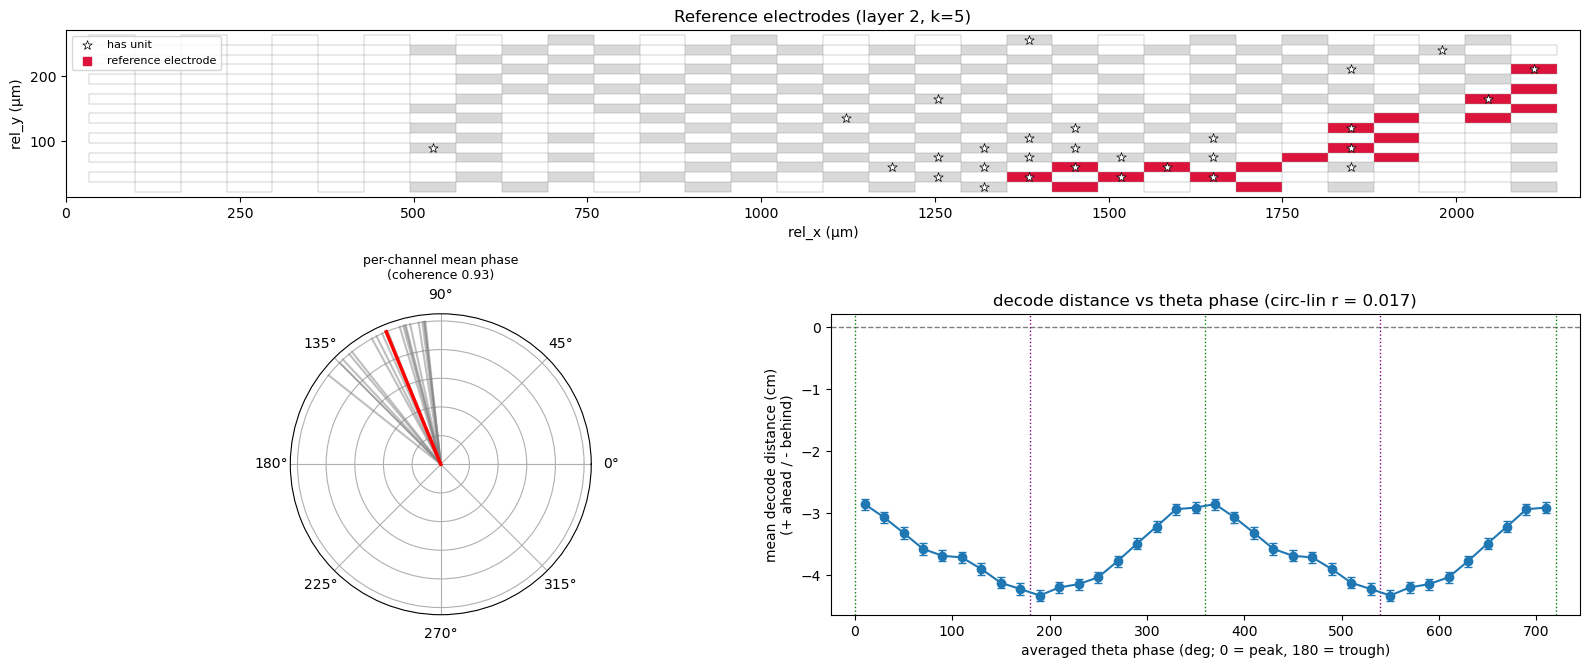

In [11]:
# Build the theta reference (average the analytic signal across the reference electrodes),
# then show: which channels they are, how in-phase they are (mean phase / coherence), and
# decode distance vs the averaged theta phase. Uses reference_electrodes from the cell above.
analytic = (HexMazeThetaV1 & {"nwb_file_name": nwb_file_name}).fetch1_analytic_signal()
z = np.column_stack([(analytic[f"electrode {e}_real"] + 1j * analytic[f"electrode {e}_imag"]).values
                     for e in reference_electrodes])
z_mean = z.mean(axis=1)                                   # averaged complex theta
theta_phase_ref = pd.Series(np.angle(z_mean), index=analytic.index, name="theta_phase")
theta_power_ref = pd.Series(np.abs(z_mean) ** 2, index=analytic.index, name="theta_power")

# Phase-averaging quality: each channel's mean phase + cross-channel coherence (1 = in phase)
channel_phase = np.angle(z)
channel_mean_phase = np.angle(np.mean(np.exp(1j * channel_phase), axis=0))
coherence = np.abs(np.mean(np.exp(1j * channel_phase), axis=1)).mean()

# Align decode distance and keep running, confident samples
decode_df = (HexMazeDecodedPosition & {"nwb_file_name": nwb_file_name}).fetch1_dataframe()
dist = decode_df["decode_distance"].reindex(theta_phase_ref.index, method="nearest")
speed = decode_df["speed"].reindex(theta_phase_ref.index, method="nearest")
cov = decode_df["spatial_cov"].reindex(theta_phase_ref.index, method="nearest")
keep = (speed.values >= 5.0) & (cov.values < 200.0) & dist.notna().values
phase_deg = np.degrees(theta_phase_ref.values[keep]) % 360   # 0 = theta peak, 180 = trough
dist_kept = dist.values[keep]

def circular_linear_corr(phase_rad, linear):
    rxc = np.corrcoef(linear, np.cos(phase_rad))[0, 1]
    rxs = np.corrcoef(linear, np.sin(phase_rad))[0, 1]
    rcs = np.corrcoef(np.cos(phase_rad), np.sin(phase_rad))[0, 1]
    return np.sqrt((rxc ** 2 + rxs ** 2 - 2 * rxc * rxs * rcs) / (1 - rcs ** 2))

clc = circular_linear_corr(np.radians(phase_deg), dist_kept)

# Binned decode distance vs theta phase
edges = np.linspace(0, 360, 19)
centers = 0.5 * (edges[:-1] + edges[1:])
bin_of = np.clip(np.digitize(phase_deg, edges) - 1, 0, len(centers) - 1)
mean_dist = np.array([dist_kept[bin_of == b].mean() for b in range(len(centers))])
sem_dist = np.array([pd.Series(dist_kept[bin_of == b]).sem() for b in range(len(centers))])
peak_phase = centers[np.nanargmax(mean_dist)]

print(f"{len(reference_electrodes)} reference electrodes | cross-channel coherence {coherence:.3f}")
print(f"decode distance vs theta phase: circular-linear r = {clc:.3f}, peaks at {peak_phase:.0f} deg "
      f"(0 = theta peak, 180 = trough)")

fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# (top) reference electrodes on the probe geometry
ax_geo = fig.add_subplot(gs[0, :])
for elec, row in electrode_geometry.iterrows():
    if pd.isna(row["rel_x"]):
        continue
    is_ref = elec in reference_electrodes
    face = "crimson" if is_ref else ("white" if is_bad.get(elec, False) else "0.85")
    ax_geo.add_patch(Rectangle((row["rel_x"] - box_width / 2, row["rel_y"] - box_height / 2),
                     box_width, box_height, facecolor=face, edgecolor="0.6", linewidth=0.3))
unit_mask = electrode_geometry.index.astype(int).isin(set(electrodes_with_units))
ax_geo.scatter(electrode_geometry.loc[unit_mask, "rel_x"], electrode_geometry.loc[unit_mask, "rel_y"],
               marker="*", s=50, c="white", edgecolors="black", linewidths=0.5, zorder=5, label="has unit")
ax_geo.scatter([], [], marker="s", color="crimson", label="reference electrode")
ax_geo.set_xlim(electrode_geometry["rel_x"].min() - box_width, electrode_geometry["rel_x"].max() + box_width)
ax_geo.set_ylim(electrode_geometry["rel_y"].min() - box_height, electrode_geometry["rel_y"].max() + box_height)
ax_geo.set_box_aspect(np.ptp(electrode_geometry["rel_y"]) / np.ptp(electrode_geometry["rel_x"]))
ax_geo.set_xlabel("rel_x (µm)")
ax_geo.set_ylabel("rel_y (µm)")
ax_geo.set_title(f"Reference electrodes (layer {REFERENCE_LAYER}, k={N_CLUSTERS})")
ax_geo.legend(loc="upper left", fontsize=8)

# (bottom-left) each reference channel's mean phase (gray) + resultant (red): clustered = clean
ax_polar = fig.add_subplot(gs[1, 0], projection="polar")
for ph in channel_mean_phase:
    ax_polar.plot([0, ph], [0, 1], color="gray", alpha=0.5)
ax_polar.plot([0, np.angle(np.mean(np.exp(1j * channel_mean_phase)))], [0, 1], color="red", lw=2.5)
ax_polar.set_yticklabels([])
ax_polar.set_title(f"per-channel mean phase\n(coherence {coherence:.2f})", fontsize=9)

# (bottom-right) decode distance vs averaged theta phase, two cycles
ax_sweep = fig.add_subplot(gs[1, 1])
x_two = np.concatenate([centers, centers + 360])
ax_sweep.errorbar(x_two, np.concatenate([mean_dist, mean_dist]),
                  yerr=np.concatenate([sem_dist, sem_dist]), marker="o", capsize=3)
ax_sweep.axhline(0, color="gray", ls="--", lw=1)
for pk in (0, 360, 720):
    ax_sweep.axvline(pk, color="green", ls=":", lw=1)
for tr in (180, 540):
    ax_sweep.axvline(tr, color="purple", ls=":", lw=1)
ax_sweep.set_xlabel("averaged theta phase (deg; 0 = peak, 180 = trough)")
ax_sweep.set_ylabel("mean decode distance (cm)\n(+ ahead / - behind)")
ax_sweep.set_title(f"decode distance vs theta phase (circ-lin r = {clc:.3f})")

plt.tight_layout()
save_fig(fig, f"{session_id}_theta_reference_summary")
plt.show()

In [12]:
# Save the chosen reference electrodes so theta phase/power can later be fetched as their
# average, without re-running the selection. reference_electrodes / N_CLUSTERS /
# REFERENCE_LAYER come from the mini selection cell above.
REFERENCE_NAME = "theta_reference_1"
HexMazeThetaReference.add_reference(
    key={"nwb_file_name": nwb_file_name},
    reference_name=REFERENCE_NAME,
    electrode_ids=reference_electrodes,
    description=f"striatum radiatum (k={N_CLUSTERS} cluster {REFERENCE_LAYER})",
    replace=True,   # overwrite if a set with this name already exists
)
display(HexMazeThetaReference & {"nwb_file_name": nwb_file_name})

# From now on, fetch the averaged theta phase / power straight from the table:
ref = HexMazeThetaReference & {"nwb_file_name": nwb_file_name, "reference_name": REFERENCE_NAME}
theta_phase_ref = ref.fetch1_reference_phase()   # radians [0, 2π], indexed by time
theta_power_ref = ref.fetch1_reference_power()    # amplitude², indexed by time
print(f"Fetched averaged theta phase/power for '{REFERENCE_NAME}' "
      f"({len(ref.fetch1('electrode_ids'))} electrodes)")

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,"reference_name label for this electrode set, e.g. ""radiatum""",electrode_ids list of electrode ids to average over,description optional note about how the set was chosen
9bd18c6f-4cf3-ac6b-2550-85fd5feadb05,Theta 5-11 Hz,1000,IM-1478_20220719_.nwb,00_r1,1000,theta_reference_1,=BLOB=,striatum radiatum (k=5 cluster 2)


[2026-06-18 17:43:03,993][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-06-18 17:43:04,005][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-06-18 17:43:38,581][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb
[2026-06-18 17:43:38,591][WARNING]: Skipped checksum for file with hash: 414788ed-c367-3135-1ef9-6b3d8ebe16f6, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_P0VHPC4NKY.nwb


Fetched averaged theta phase/power for 'theta_reference_1' (19 electrodes)
